# 高含水を説明する特徴量 EDA

**目的**: 水バンド(O-H)は高含水で飽和して情報が消える一方、乾物(C-H/セルロース・リグニン)バンドは質量希釈で抑制され続け高MCの勾配を保つ、という仮説をスペクトルと相関で可視化する。

- 水バンド: O-H 1450 / 1940 / 2000-2100 nm
- 乾物バンド(候補): C-H sg2 1700-1740 / 2300-2340 / sg1 1260-1300 nm
- 検証樹種: **ベイスギ**(MC最大298%, 他樹種は最大216%) = 外挿が必要な極値
- 指標: 全体相関 vs **高MC域(>120%)内の相関**(飽和の有無)

In [1]:
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import spearmanr
matplotlib.rcParams['font.family'] = ['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110

tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
META = ['sample number','species number','樹種','含水率']
wn_cols = [c for c in tr.columns if c not in META]
wn = np.array([float(c) for c in wn_cols]); wl = 1e7 / wn   # cm-1 -> nm
order = np.argsort(wl); nm = wl[order]
X  = tr[wn_cols].values.astype(float)[:, order]            # 生スペクトル(nm昇順)
mc = tr['含水率'].values.astype(float)
sp = tr['樹種'].values
species = np.unique(sp)

snv = lambda M: (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-8)
sg  = lambda M, d: savgol_filter(M, 11, 2, deriv=d, axis=1)
S, S1, S2 = snv(X), sg(snv(X),1), sg(snv(X),2)
print('train', X.shape, '| nm %.0f-%.0f' % (nm.min(), nm.max()),
      '| MC %.1f-%.1f%%' % (mc.min(), mc.max()), '| 樹種', len(species))

train (1270, 1555) | nm 1001-2500 | MC 0.8-298.6% | 樹種 13


## 1. MCビン別の平均スペクトル
水バンドが高MCで飽和(MCが上がっても深さが増えない)、乾物バンドが希釈で抑制されるかを見る。

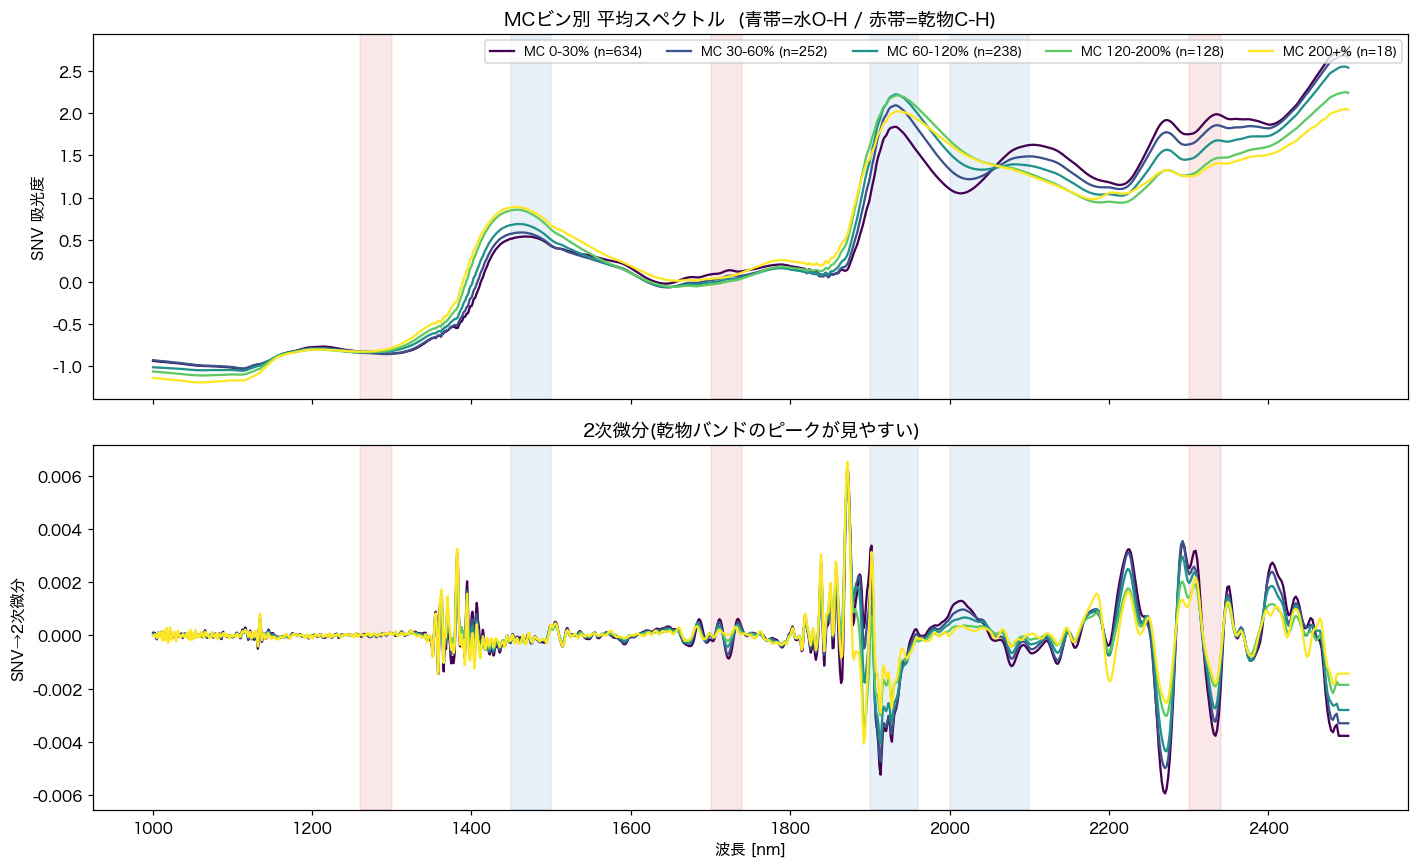

In [2]:
WATER = {'O-H 1450':(1450,1500),'O-H 1940':(1900,1960),'O-H 2000-2100':(2000,2100)}
DRY   = {'C-H 1270':(1260,1300),'C-H 1715':(1700,1740),'C-H 2320':(2300,2340)}

bins   = [0,30,60,120,200,310]
labels = ['0-30','30-60','60-120','120-200','200+']
cidx   = np.digitize(mc, bins) - 1
cols   = plt.cm.viridis(np.linspace(0,1,len(labels)))

fig, ax = plt.subplots(2,1, figsize=(13,8), sharex=True)
for k in range(len(labels)):
    m = cidx==k
    ax[0].plot(nm, S[m].mean(0),  color=cols[k], label=f'MC {labels[k]}% (n={m.sum()})')
    ax[1].plot(nm, S2[m].mean(0), color=cols[k])
for a in ax:
    for lo,hi in WATER.values(): a.axvspan(lo,hi,color='C0',alpha=.10)
    for lo,hi in DRY.values():   a.axvspan(lo,hi,color='C3',alpha=.10)
ax[0].set_ylabel('SNV 吸光度'); ax[0].legend(fontsize=8, ncol=5, loc='upper right')
ax[0].set_title('MCビン別 平均スペクトル  (青帯=水O-H / 赤帯=乾物C-H)')
ax[1].set_ylabel('SNV→2次微分'); ax[1].set_xlabel('波長 [nm]')
ax[1].set_title('2次微分(乾物バンドのピークが見やすい)')
plt.tight_layout(); plt.show()

## 2. 特徴量の定義と MCとの散布図
水バンド(飽和)と乾物バンド(高MCで勾配維持)を並べる。ベイスギを赤で強調。

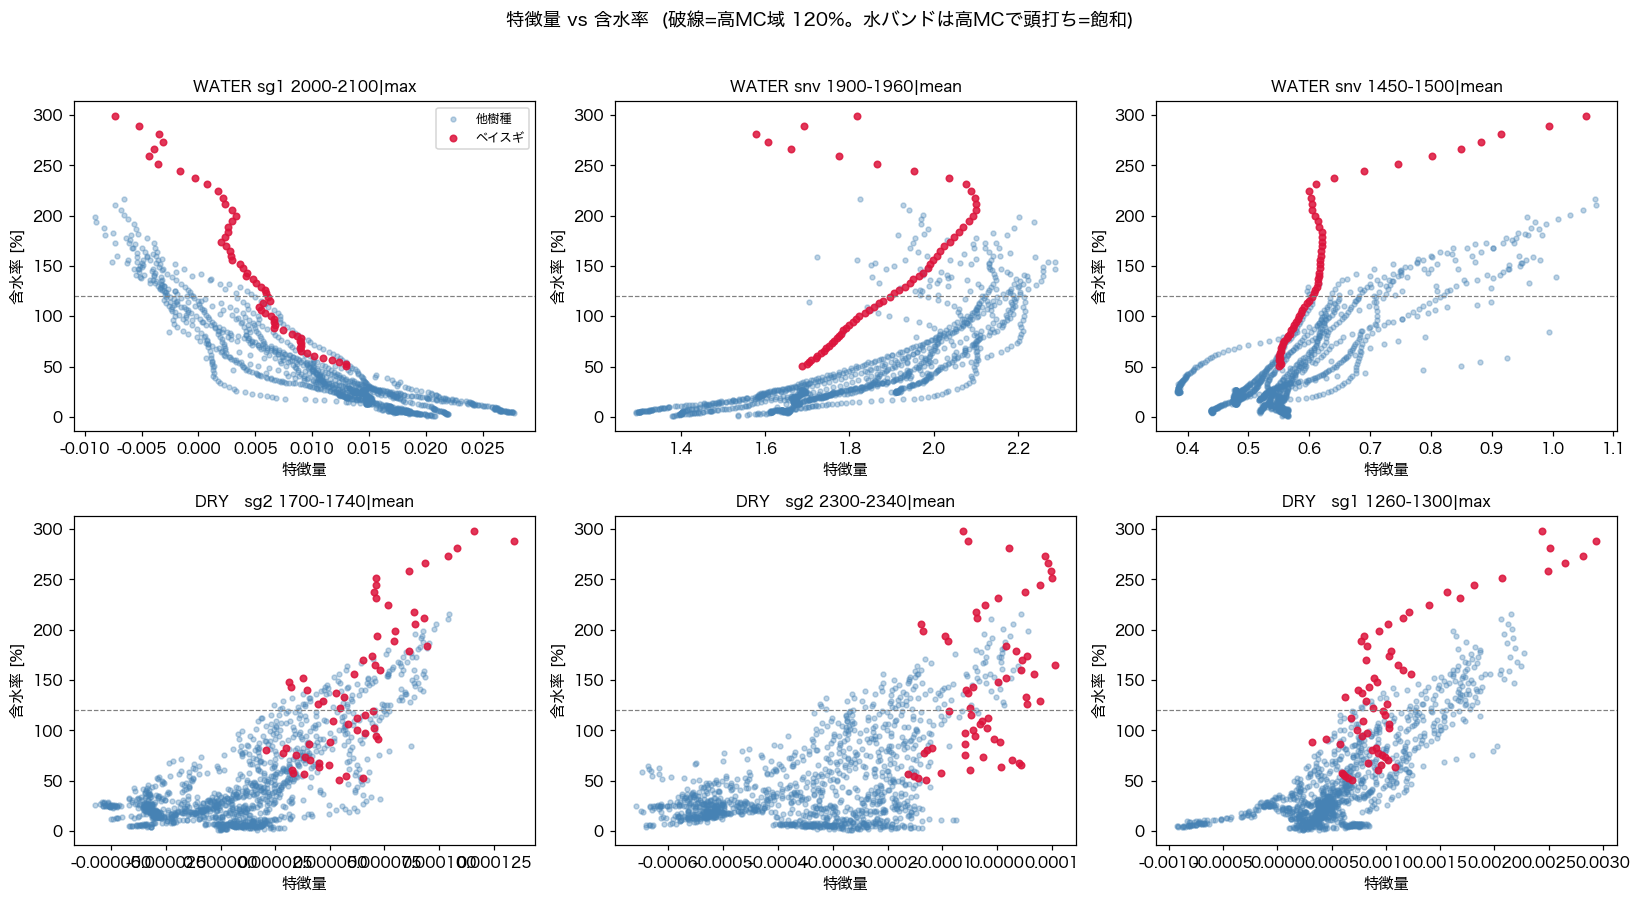

In [3]:
bd = lambda M,lo,hi: M[:, (nm>=lo)&(nm<=hi)]
feats = {
  'WATER sg1 2000-2100|max': bd(S1,2000,2100).max(1),
  'WATER snv 1900-1960|mean': bd(S,1900,1960).mean(1),
  'WATER snv 1450-1500|mean': bd(S,1450,1500).mean(1),
  'DRY   sg2 1700-1740|mean': bd(S2,1700,1740).mean(1),
  'DRY   sg2 2300-2340|mean': bd(S2,2300,2340).mean(1),
  'DRY   sg1 1260-1300|max':  bd(S1,1260,1300).max(1),
}
ced = sp=='ベイスギ'
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax,(name,v) in zip(axes.ravel(), feats.items()):
    ax.scatter(v[~ced], mc[~ced], s=10, alpha=.35, c='steelblue', label='他樹種')
    ax.scatter(v[ced],  mc[ced],  s=18, alpha=.85, c='crimson',   label='ベイスギ')
    ax.set_title(name, fontsize=10); ax.set_xlabel('特徴量'); ax.set_ylabel('含水率 [%]')
    ax.axhline(120, color='gray', ls='--', lw=.8)
axes[0,0].legend(fontsize=8)
plt.suptitle('特徴量 vs 含水率  (破線=高MC域 120%。水バンドは高MCで頭打ち=飽和)', y=1.02)
plt.tight_layout(); plt.show()

## 3. 相関: 全体 vs 高MC域(>120%)
高MC域でも相関が残る=飽和していない=外挿に使える特徴。

高MC域 n=146 (うちベイスギ 33)


,spearman_all,spearman_highMC
feature,,
WATER sg1 2000-2100|max,-0.920,-0.405
WATER snv 1900-1960|mean,0.869,-0.286
WATER snv 1450-1500|mean,0.639,0.355
DRY sg2 1700-1740|mean,0.629,0.648
DRY sg2 2300-2340|mean,0.457,0.598
DRY sg1 1260-1300|max,0.706,0.425


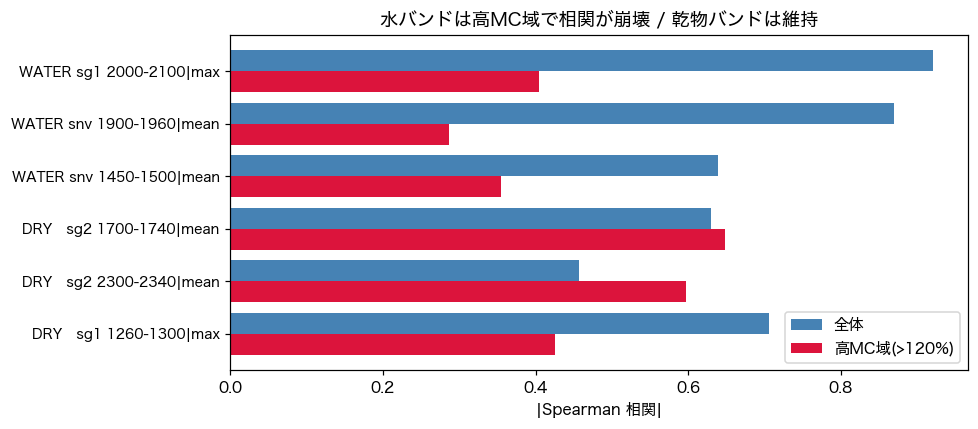

In [4]:
hi = mc>120
rows = []
for name,v in feats.items():
    rows.append([name, spearmanr(v,mc).correlation, spearmanr(v[hi],mc[hi]).correlation])
corr = pd.DataFrame(rows, columns=['feature','spearman_all','spearman_highMC']).set_index('feature')
print(f'高MC域 n={hi.sum()} (うちベイスギ {(hi&ced).sum()})')
display(corr.round(3))

fig, ax = plt.subplots(figsize=(9,4))
y = np.arange(len(corr))
ax.barh(y-0.2, corr.spearman_all.abs(),    0.4, label='全体', color='steelblue')
ax.barh(y+0.2, corr.spearman_highMC.abs(), 0.4, label='高MC域(>120%)', color='crimson')
ax.set_yticks(y); ax.set_yticklabels(corr.index, fontsize=9); ax.invert_yaxis()
ax.set_xlabel('|Spearman 相関|'); ax.legend()
ax.set_title('水バンドは高MC域で相関が崩壊 / 乾物バンドは維持')
plt.tight_layout(); plt.show()

## 4. 飽和の直接確認: 同じ特徴量値でベイスギのMCは他樹種の何倍か

In [5]:
fw = feats['WATER sg1 2000-2100|max']
low = fw < np.percentile(fw, 15)   # 高MCに対応する低特徴域
print('水バンド低特徴域(高MC側) のMC平均:')
print('  他樹種  : %.0f%%' % mc[low&~ced].mean())
print('  ベイスギ: %.0f%%' % mc[low&ced].mean())
print('  -> 同一特徴量値でベイスギは %.1f倍 = 外挿ではなく飽和' %
      (mc[low&ced].mean()/mc[low&~ced].mean()))

水バンド低特徴域(高MC側) のMC平均:
  他樹種  : 129%
  ベイスギ: 263%
  -> 同一特徴量値でベイスギは 2.0倍 = 外挿ではなく飽和


## 5. 樹種別の特徴-MC関係 (乾物バンドが樹種をまたいで揃うか)

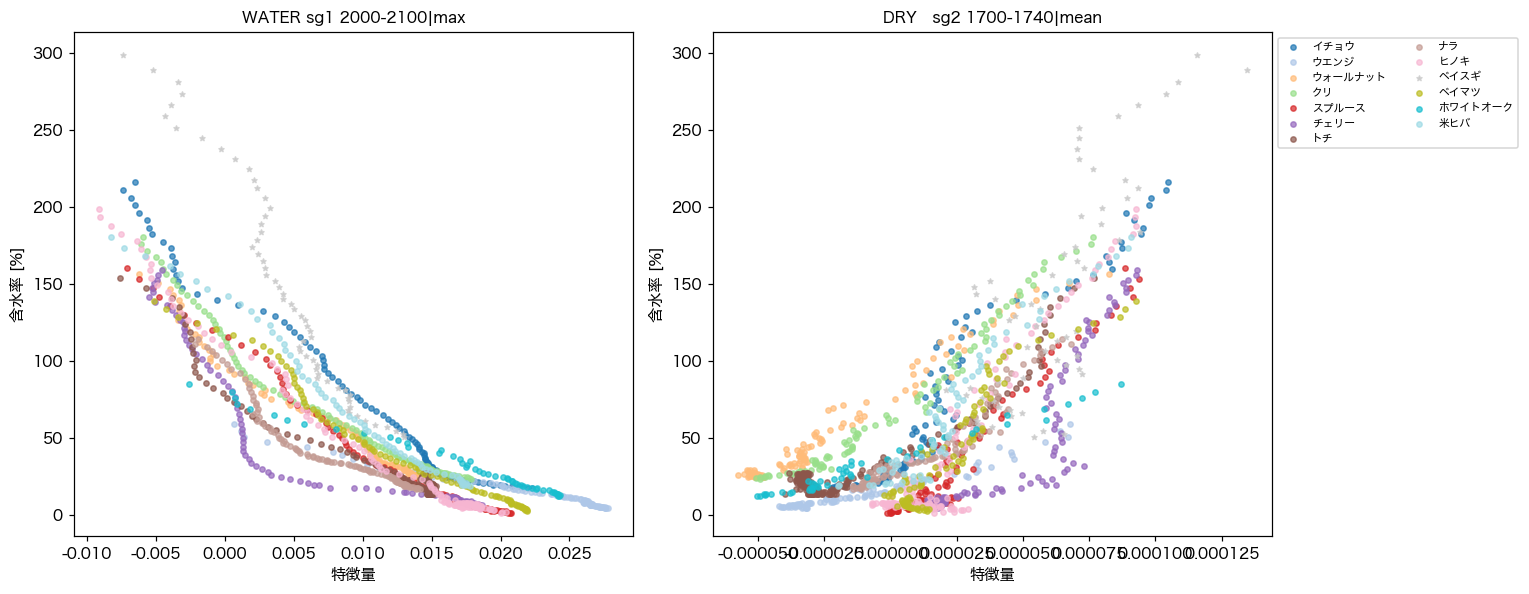

In [6]:
fig, ax = plt.subplots(1,2, figsize=(14,5.5))
pairs = [('WATER sg1 2000-2100|max', ax[0]), ('DRY   sg2 1700-1740|mean', ax[1])]
cmap = plt.cm.tab20(np.linspace(0,1,len(species)))
for name,a in pairs:
    v = feats[name]
    for c,s in zip(cmap, species):
        m = sp==s
        a.scatter(v[m], mc[m], s=12, alpha=.7, color=c,
                  label=s, marker=('*' if s=='ベイスギ' else 'o'))
    a.set_title(name, fontsize=10); a.set_xlabel('特徴量'); a.set_ylabel('含水率 [%]')
ax[1].legend(fontsize=7, ncol=2, loc='upper left', bbox_to_anchor=(1.0,1.0))
plt.tight_layout(); plt.show()